# 6차시 정답 Notebook — 그래프로 공정 상태 이해하기

각 코드 셀 맨 위의 `#` 주석은 그 셀이 무엇을 하는지, 실행하면 무엇이 보이는지 알려줍니다. 그래프가 겹치지 않도록 한 셀에 그래프 하나만 두었습니다(강의 자료 체크포인트 "그래프가 겹쳐 보인다면").

## 1단계. 데이터 준비

In [1]:
# 오늘 쓸 도구 두 가지를 불러오고 그래프의 한글 글꼴을 정한 뒤, 실습 CSV 파일을 읽어 df라는 표에 저장합니다.
# 실행하면 표의 앞 5행이 보입니다 — 측정시간 열의 값이 "2024-03-01 05:00" 같은 글자(문자열)라는 점을 눈여겨보세요.
import pandas as pd
# import matplotlib.pyplot as plt: 그래프를 그리는 도구(matplotlib)를 plt라는 짧은 이름으로 불러옵니다.
import matplotlib.pyplot as plt
# plt.rcParams["설정 이름"] = 값: 이후 그리는 모든 그래프에 적용되는 기본 설정을 바꿉니다.
plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 글꼴(Windows). Mac은 "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False      # 음수 부호(-)가 네모로 깨지지 않게

df = pd.read_csv("../../data/weekly/week06/week06_process_visualization.csv")
df.head()  # (중간 확인)

,측정시간,로트번호,설비번호,공정명,온도_섭씨,압력_Pa,두께_nm,진동_mm_s,처리시간_sec,합격여부
0,2024-03-01 05:00,LOT-0472,EQ-04,식각,295.6,1026.3,97.35,0.507,124.3,-1
1,2024-03-01 17:00,LOT-0206,EQ-04,증착,301.6,1008.5,99.79,0.487,123.5,1
2,2024-03-01 19:00,LOT-0403,EQ-04,포토,300.8,1006.1,99.34,0.501,114.9,1
3,2024-03-02 00:00,LOT-0468,EQ-01,식각,297.8,1010.0,95.23,0.467,117.0,1
4,2024-03-02 03:00,LOT-0117,EQ-01,산화,299.5,1014.7,100.53,0.544,115.2,1


In [2]:
# 측정시간 열을 날짜/시간 형식으로 바꾼 뒤, 시간 순서대로 행을 정렬합니다.
# 실행하면 측정시간 앞 5개 값이 나옵니다 — 맨 아래 dtype이 datetime64[ns](날짜/시간 형식)로 바뀌었는지 확인해 보세요.
# 글자로 된 날짜를 날짜/시간 값으로 바꿔 두면, 그래프의 x축이 실제 시간 간격대로 그려집니다.
df["측정시간"] = pd.to_datetime(df["측정시간"])   # 문자열 → 날짜/시간 형식
# sort_values("열 이름"): 그 열을 기준으로 작은 값(이른 시간)부터 행을 정렬합니다(4차시).
df = df.sort_values("측정시간")
df["측정시간"].head()  # (중간 확인)

0   2024-03-01 05:00:00
1   2024-03-01 17:00:00
2   2024-03-01 19:00:00
3   2024-03-02 00:00:00
4   2024-03-02 03:00:00
Name: 측정시간, dtype: datetime64[ns]

## 2단계. 선 그래프 — 시간에 따른 온도 변화

### 따라 해보기 — 아주 간단한 선 그래프
반도체 데이터로 들어가기 전에, 일주일간의 최고기온처럼 익숙한 데이터로 선 그래프부터 그려 봅니다
(강의 자료 "먼저 아주 간단한 예로 감을 잡자"). 완성된 코드이니 실행해서 결과를 확인하세요.

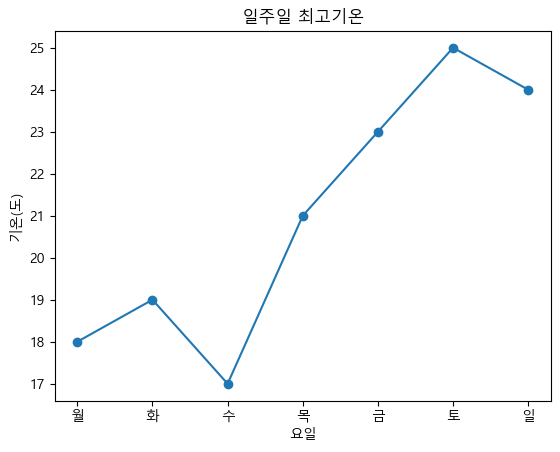

In [3]:
# 요일 7개와 그날의 최고기온 7개를 리스트로 만들고, 요일에 따른 기온 변화를 선 그래프로 그립니다.
# 실행하면 월~일 7개 점이 선으로 이어진 그래프가 나옵니다 — 목요일부터 토요일까지 계속 오르는 모양을 확인해 보세요.
days = ["월", "화", "수", "목", "금", "토", "일"]
temps = [18, 19, 17, 21, 23, 25, 24]

# plt.plot(x값 목록, y값 목록): 점을 순서대로 이어 선 그래프를 그립니다. marker="o"는 점마다 동그라미를 찍습니다.
plt.plot(days, temps, marker="o")
# plt.title / plt.xlabel / plt.ylabel: 그래프 제목, x축 이름, y축 이름을 붙입니다.
plt.title("일주일 최고기온")
plt.xlabel("요일")
plt.ylabel("기온(도)")
# plt.show(): 지금까지 그린 그래프를 화면에 보여주고 마무리합니다. 다음 그래프는 새 그림에서 시작됩니다.
plt.show()

### 반도체 데이터에 적용하기 — 시간에 따른 온도 변화

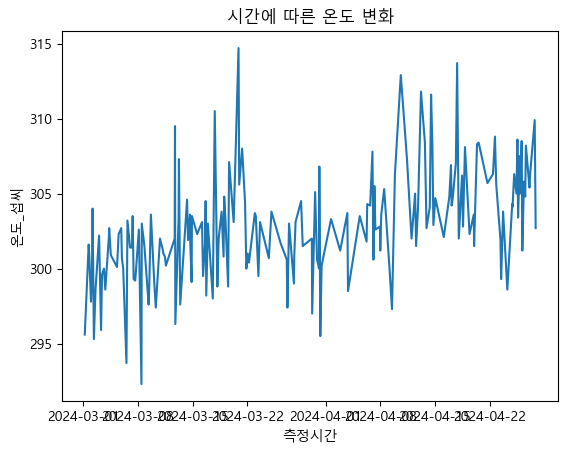

In [4]:
# 같은 방법으로 반도체 데이터의 측정시간(x축)에 따른 온도_섭씨(y축) 변화를 선 그래프로 그립니다.
# 실행하면 180개 측정값이 시간 순서대로 이어진 선이 나옵니다 — 시간이 지날수록 선이 완만하게 올라가는지(드리프트) 보세요.
plt.plot(df["측정시간"], df["온도_섭씨"])
plt.title("시간에 따른 온도 변화")
plt.xlabel("측정시간")
plt.ylabel("온도_섭씨")
plt.show()

## 3단계. 막대그래프 — 설비별 측정 건수

### 따라 해보기 — 아주 간단한 막대그래프
과일별 판매량처럼 범주를 비교하는 익숙한 예로 막대그래프부터 그려 봅니다. 완성된 코드이니 실행해서 결과를 확인하세요.

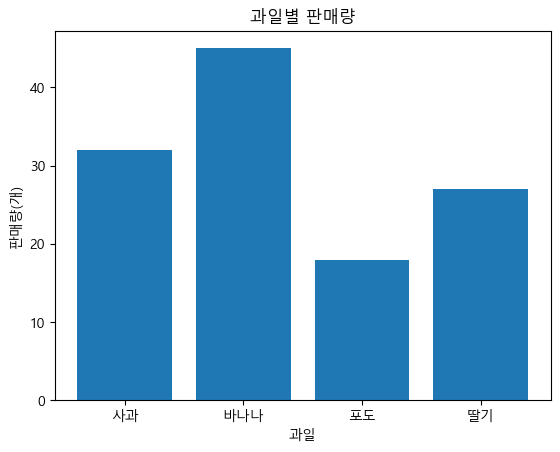

In [5]:
# 과일 4종류와 판매량을 리스트로 만들고, 과일별 판매량을 막대그래프로 그립니다.
# 실행하면 막대 4개가 나옵니다 — 가장 높은 막대(바나나 45개)와 가장 낮은 막대(포도 18개)를 찾아보세요.
fruits = ["사과", "바나나", "포도", "딸기"]
sales = [32, 45, 18, 27]

# plt.bar(범주 목록, 값 목록): 범주마다 값만큼의 높이로 막대를 세웁니다.
plt.bar(fruits, sales)
plt.title("과일별 판매량")
plt.xlabel("과일")
plt.ylabel("판매량(개)")
plt.show()

### 반도체 데이터에 적용하기 — 설비별 측정 건수

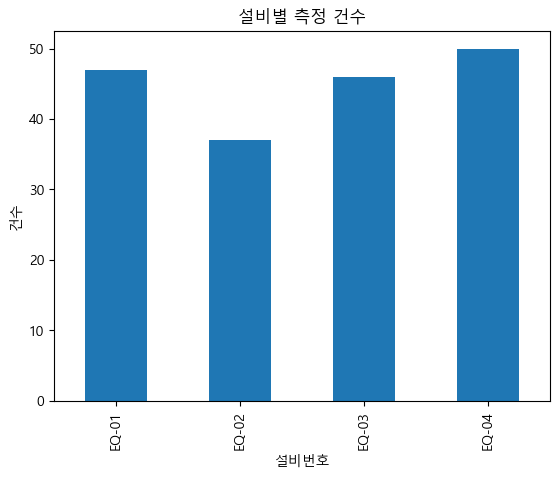

In [6]:
# 설비번호마다 측정 기록이 몇 건인지 센 다음, 설비 이름 순서로 정렬해 막대그래프로 그립니다.
# 실행하면 EQ-01~EQ-04 막대 4개가 나옵니다 — EQ-02 막대만 조금 낮은지(37건) 확인해 보세요.
# 값별 개수를 센 결과에 .sort_index()를 붙이면 이름(EQ-01, EQ-02, ...) 순서로 정렬되고, .plot(kind="bar")를 붙이면 바로 막대그래프가 그려집니다.
df["설비번호"].value_counts().sort_index().plot(kind="bar")
plt.title("설비별 측정 건수")
plt.xlabel("설비번호")
plt.ylabel("건수")
plt.show()

## 4단계. 히스토그램 — 온도 분포

### 따라 해보기 — 아주 간단한 히스토그램
학생 20명의 시험 점수로 히스토그램부터 그려 봅니다. 완성된 코드이니 실행해서 결과를 확인하세요.

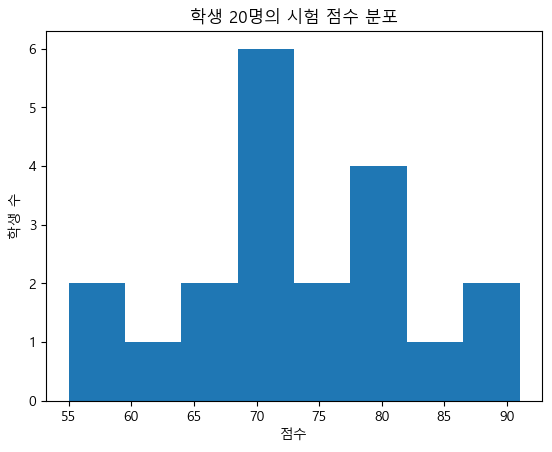

In [7]:
# 학생 20명의 시험 점수를 리스트로 만들고, 점수가 어느 구간에 몰려 있는지 히스토그램으로 그립니다.
# 실행하면 막대 8개가 붙어 있는 그래프가 나옵니다 — 70점 근처 구간 막대가 가장 높은지(6명) 확인해 보세요.
# 학생 20명의 시험 점수(연습용 예시 값)
scores = [55, 62, 68, 70, 72, 58, 71, 74, 78, 66, 80, 69, 85, 72, 79, 88, 71, 76, 81, 91]

# plt.hist(값 목록, bins=구간 개수): 가장 작은 값~가장 큰 값을 bins개 구간으로 똑같이 나누고, 구간마다 몇 개가 들어가는지 막대로 그립니다.
plt.hist(scores, bins=8)
plt.title("학생 20명의 시험 점수 분포")
plt.xlabel("점수")
plt.ylabel("학생 수")
plt.show()

### 반도체 데이터에 적용하기 — 온도 분포

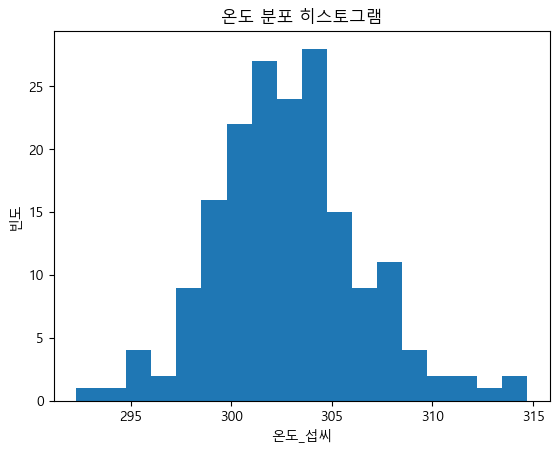

In [8]:
# 반도체 데이터의 온도_섭씨 값 180개를 18개 구간으로 나눠 온도 분포 히스토그램을 그립니다.
# 실행하면 300℃ 부근에 봉우리가 하나 솟은 종 모양 그래프가 나오는지 확인해 보세요.
plt.hist(df["온도_섭씨"], bins=18)
plt.title("온도 분포 히스토그램")
plt.xlabel("온도_섭씨")
plt.ylabel("빈도")
plt.show()

## 5단계. 산점도 — 온도와 두께의 관계

### 따라 해보기 — 아주 간단한 산점도
"공부 시간이 늘수록 시험 점수도 오를까?"라는 익숙한 예로 산점도부터 그려 봅니다. 완성된 코드이니 실행해서 결과를 확인하세요.

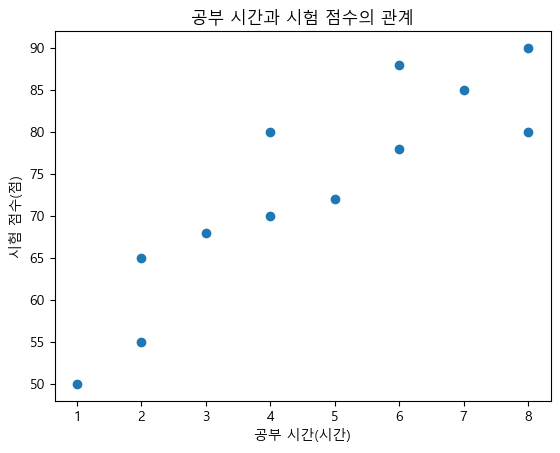

In [9]:
# 학생 12명의 공부 시간과 시험 점수를 리스트로 만들고, 둘의 관계를 산점도로 그립니다.
# 실행하면 점 12개가 찍힌 그래프가 나옵니다 — 점들이 대체로 오른쪽 위로 향하는지 보세요.
study_hours = [1, 2, 2, 3, 4, 4, 5, 6, 6, 7, 8, 8]
exam_scores = [50, 65, 55, 68, 70, 80, 72, 88, 78, 85, 90, 80]

# plt.scatter(x값 목록, y값 목록): 같은 순서의 두 값을 한 쌍으로 묶어 점 하나씩 찍습니다(점 하나 = 학생 한 명).
plt.scatter(study_hours, exam_scores)
plt.title("공부 시간과 시험 점수의 관계")
plt.xlabel("공부 시간(시간)")
plt.ylabel("시험 점수(점)")
plt.show()

### 반도체 데이터에 적용하기 — 온도와 두께의 관계

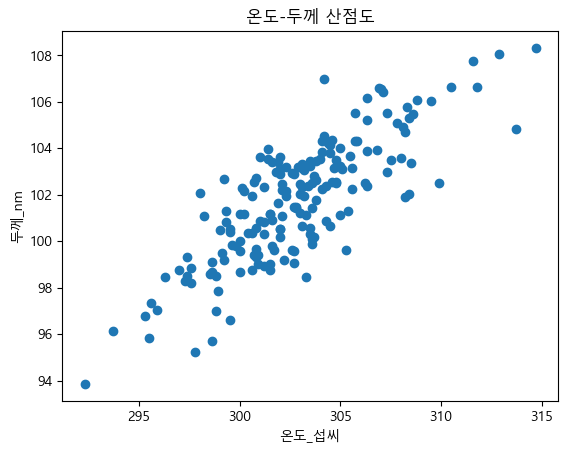

In [10]:
# 반도체 데이터의 온도_섭씨(x축)와 두께_nm(y축)을 산점도로 그립니다. 점 하나가 측정 기록 하나입니다.
# 실행하면 점 180개가 찍힌 그래프가 나옵니다 — 점들이 오른쪽 위로 향하는지(온도가 높을수록 두께도 두꺼운지) 보세요.
plt.scatter(df["온도_섭씨"], df["두께_nm"])
plt.title("온도-두께 산점도")
plt.xlabel("온도_섭씨")
plt.ylabel("두께_nm")
plt.show()

In [11]:
# 온도_섭씨와 두께_nm이 얼마나 함께 움직이는지 상관계수 하나로 계산해 출력합니다.
# 실행하면 0.81 정도의 숫자가 나옵니다 — 1에 가까울수록 강한 양의 관계입니다. 다만 관계가 있어 보일 뿐, 온도가 두께의 원인이라고 단정할 수는 없습니다(8차시).
# 열1.corr(열2): 두 열의 상관계수(-1~1 사이 값)를 구합니다.
print(df["온도_섭씨"].corr(df["두께_nm"]))

0.811049835578712


## 6단계. 박스플롯 — 설비별 온도 분포

### 따라 해보기 — 아주 간단한 박스플롯
A반·B반·C반의 시험 점수로 박스플롯부터 그려 봅니다. 완성된 코드이니 실행해서 결과를 확인하세요.

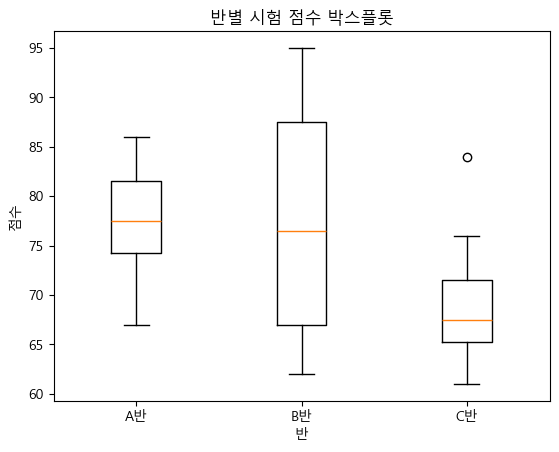

In [12]:
# A반·B반·C반 학생 10명씩의 시험 점수를 리스트로 만들고, 반별 점수 분포를 박스플롯으로 나란히 그립니다.
# 실행하면 상자 3개가 나옵니다 — 상자와 수염이 가장 긴 반(B반)과, 수염 밖에 동그라미로 찍힌 점(C반의 이상치)을 찾아보세요.
# 반마다 학생 10명의 시험 점수(연습용 예시 값)
classA = [70, 75, 80, 77, 83, 74, 86, 67, 78, 82]
classB = [62, 66, 70, 95, 88, 75, 86, 64, 78, 91]
classC = [64, 67, 61, 70, 66, 72, 65, 68, 76, 84]

# plt.boxplot([목록1, 목록2, ...], tick_labels=[이름들]): 목록마다 상자를 하나씩 그리고 x축에 이름을 붙입니다(tick_labels는 matplotlib 3.9 이상).
plt.boxplot([classA, classB, classC], tick_labels=["A반", "B반", "C반"])
plt.title("반별 시험 점수 박스플롯")
plt.xlabel("반")
plt.ylabel("점수")
plt.show()

### 반도체 데이터에 적용하기 — 설비별 온도
반도체 데이터는 이미 표(DataFrame) 형태라서, pandas의 `df.boxplot(column=, by=)`로 그룹별 분리까지 한 번에 처리합니다.

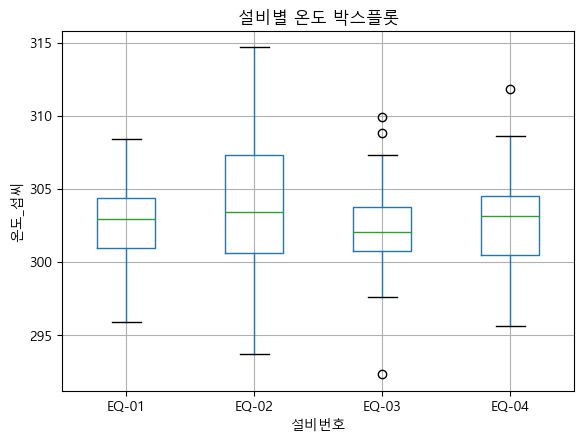

In [13]:
# 설비번호별로 온도_섭씨 값을 나눠, 설비 4대의 온도 박스플롯을 한 그림에 나란히 그립니다.
# 실행하면 상자 4개가 나옵니다 — 상자와 수염이 가장 넓게 퍼진 설비가 어디인지 찾아보세요.
# 표(DataFrame)에서 바로 그리는 박스플롯은 column=에 값을 볼 열, by=에 그룹을 나눌 열을 넣습니다.
df.boxplot(column="온도_섭씨", by="설비번호")
plt.title("설비별 온도 박스플롯")
plt.suptitle("")   # 자동으로 붙는 부제목 제거
plt.xlabel("설비번호")
plt.ylabel("온도_섭씨")
plt.show()

## 7단계(종합). 숫자로 다시 확인하기

In [14]:
# 설비번호별로 묶어서, 설비마다 온도_섭씨 표준편차(값이 평균에서 얼마나 퍼져 있는지)를 계산해 출력합니다.
# 실행하면 설비 4대의 표준편차가 나옵니다 — 6단계 박스플롯에서 가장 넓게 퍼졌던 설비의 숫자가 가장 큰지 확인해 보세요.
# 그룹으로 묶는 함수 뒤에 ["값 열"].std()를 붙이면 그룹마다 표준편차가 나옵니다(묶는 방법은 7차시에서 자세히 배웁니다).
print(df.groupby("설비번호")["온도_섭씨"].std())

설비번호
EQ-01    3.216079
EQ-02    5.370920
EQ-03    3.053273
EQ-04    3.018731
Name: 온도_섭씨, dtype: float64


## 8단계. 오늘의 학습을 한 문장으로 정리하기

> EQ-02는 온도 표준편차가 가장 크고, 온도와 두께 사이에는 뚜렷한 양의 상관관계가 있다.

### 도전 문제 1 — 설비별 진동 박스플롯 (빠른 학습자용)
강의 자료 「도전 실습」 문제입니다. 6단계 온도 박스플롯과 같은 방법으로 **진동_mm_s** 열의 설비별 박스플롯을 그리고,
온도에서 가장 넓게 퍼졌던 설비(EQ-02)가 진동에서도 가장 넓게 퍼져 있는지 확인합니다. 마지막 칸에는 이 결과로 떠올릴 수
있는 "원인 후보"를 한 문장으로 적어 보세요.

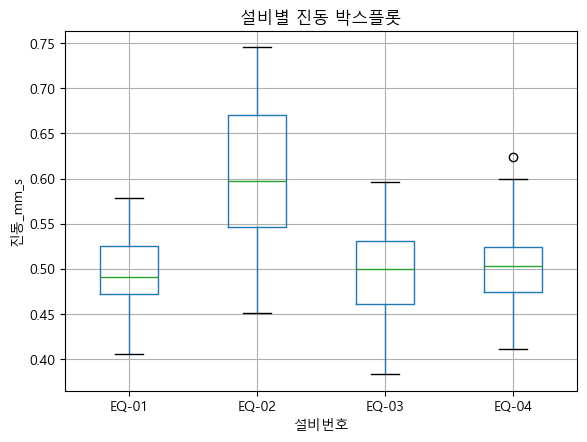

In [15]:
# 온도 대신 진동_mm_s 열로, 6단계 온도 박스플롯과 같은 방법의 설비별 박스플롯을 그립니다.
# 실행하면 설비 4대의 진동 박스플롯이 나옵니다 — 온도에서 가장 넓게 퍼졌던 설비(EQ-02)의 상자와 수염이 진동에서도 가장 넓은지 보세요.
df.boxplot(column="진동_mm_s", by="설비번호")
plt.title("설비별 진동 박스플롯")
plt.suptitle("")   # 자동으로 붙는 부제목 제거
plt.xlabel("설비번호")
plt.ylabel("진동_mm_s")
plt.show()

> **참고**
> - 빈칸 ① — 강의 자료 「② 파이썬으로 확인하기 — 다섯 가지 그래프」의 「5. 박스플롯 — 그룹별 분포와 이상값」에서
>   반도체 데이터에 적용한 코드 블록 첫 줄을 다시 보세요. 표(DataFrame)에 바로 붙여 쓰는 박스플롯 메서드로,
>   그룹별로 상자를 나눠 그리는 일까지 한 번에 해 줍니다.
> - 빈칸 ② — 같은 줄에서 `column=` 다음에 오는 인자입니다. `column=`이 "값을 볼 열"이라면, 이 인자는 "무엇을 기준으로
>   그룹을 나눌지"(여기서는 설비번호)를 정합니다. 강의 자료 「도전 실습」 상자에도 같은 코드가 있습니다.
>
> **정답 해설:** ① `boxplot`, ② `by` — `df.boxplot(column="진동_mm_s", by="설비번호")`는 진동_mm_s 값을 설비번호별로
> 나눠 상자를 그립니다. 6단계 온도 박스플롯에서 `column=`의 열 이름만 `진동_mm_s`로 바꾼 것입니다.

In [16]:
# 진동의 퍼짐도 숫자로 확인합니다. 7단계와 같은 방법으로 설비마다 진동_mm_s 표준편차를 계산해 출력합니다.
# 실행하면 설비 4대의 진동 표준편차가 나옵니다 — 바로 위 박스플롯에서 가장 넓게 퍼졌던 설비의 숫자가 가장 큰지 확인해 보세요.
print(df.groupby("설비번호")["진동_mm_s"].std())

설비번호
EQ-01    0.038440
EQ-02    0.076806
EQ-03    0.050449
EQ-04    0.039091
Name: 진동_mm_s, dtype: float64


**원인 후보 한 문장 (예시 답안)**: EQ-02는 온도와 진동이 모두 다른 설비보다 넓게 퍼져 있으므로, EQ-02의 설비
상태가 불안정한 것이 원인 후보로 떠오른다. 다만 이 그래프만으로 원인이라고 단정할 수는 없다(8차시에서 다룬다).

## 9단계. AI에게 질문하며 더 알아보기
오늘 배운 그래프 그리기에 대해 AI 챗봇에게 질문해 이해를 넓혀봅니다.

질문 예시:
- "matplotlib에서 그래프에 한글이 깨질 때는 어떻게 해결하나요?"
- "산점도(scatter)와 선그래프(line) 중 어떤 경우에 어떤 그래프를 써야 하나요?"
- "박스플롯(boxplot)에서 상자 밖에 찍힌 점들은 무엇을 의미하나요?"
- "seaborn이라는 라이브러리는 matplotlib과 어떻게 다른가요?"

## 10단계. AI에게 코드 생성 요청하고 직접 실행해보기
프롬프트 예시: "두 숫자 리스트로 산점도를 그리고, 상관계수를 그래프 제목에 함께 표시해주는
코드를 만들어줘."

아래는 AI가 생성해줄 수 있는 예시 코드입니다.

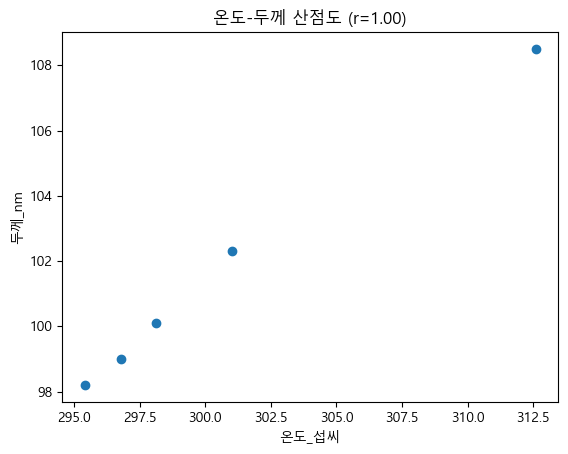

In [17]:
# AI가 만들어 줄 수 있는 예시 코드입니다(강의 자료와 같음). 온도 5개·두께 5개 리스트로 산점도를 그리고, 상관계수를 제목에 함께 표시합니다.
# 실행하면 점 5개짜리 산점도가 나오고 제목 끝에 (r=1.00)이 붙습니다 — 점 5개가 거의 한 줄로 놓여 상관계수가 1에 매우 가깝기 때문입니다.
import pandas as pd
import matplotlib.pyplot as plt

temps = [295.4, 298.1, 312.6, 301.0, 296.8]
thickness = [98.2, 100.1, 108.5, 102.3, 99.0]

# pd.Series(리스트): 리스트를 pandas의 한 줄짜리 데이터로 바꿔서 .corr()로 상관계수를 구할 수 있게 합니다.
r = pd.Series(temps).corr(pd.Series(thickness))

plt.scatter(temps, thickness)
# f"...{r:.2f}": 제목 글자 안에 r 값을 소수점 둘째 자리까지 끼워 넣는 f-string입니다(1차시 복습).
plt.title(f"온도-두께 산점도 (r={r:.2f})")
plt.xlabel("온도_섭씨")
plt.ylabel("두께_nm")
plt.show()

## 11단계. 연습문제 — 설비별 평균 온도 막대그래프
3단계에서는 `value_counts()`로 설비별 측정 건수를 막대그래프로 그렸습니다. 이번에는 `groupby`로
설비별 평균 온도를 계산해 막대그래프로 그립니다.

In [18]:
# 설비번호별로 묶어 설비마다 온도_섭씨 평균을 계산해 avg_temp_by_eq에 저장하고, 그래프를 그리기 전에 값을 먼저 확인합니다.
# 실행하면 설비 4대의 평균 온도가 나옵니다 — 네 값이 모두 302~304℃ 근처로 비슷한지 보세요.
# .mean(): 그룹마다 평균을 구합니다(7단계에서 .std()를 쓴 자리에 .mean()을 쓴 것입니다).
avg_temp_by_eq = df.groupby("설비번호")["온도_섭씨"].mean()
print(avg_temp_by_eq)  # (중간 확인)

설비번호
EQ-01    302.834043
EQ-02    303.735135
EQ-03    302.241304
EQ-04    302.746000
Name: 온도_섭씨, dtype: float64


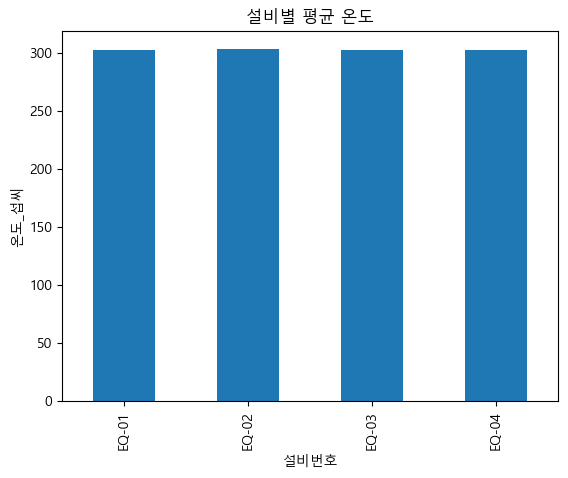

In [19]:
# 바로 위에서 계산한 설비별 평균 온도를 막대그래프로 그립니다. 그리는 방법은 3단계(건수 막대그래프)와 같습니다.
# 실행하면 막대 4개의 높이가 거의 같아 보일 것입니다 — 평균은 비슷하고, 설비 사이의 차이는 7단계에서 본 '퍼짐'에 있다는 뜻입니다.
avg_temp_by_eq.plot(kind="bar")
plt.title("설비별 평균 온도")
plt.ylabel("온도_섭씨")
plt.show()

## 12단계. AI로 재미있는 미니 프로그램 만들기 🎉 — 나만의 이모지 막대그래프
프롬프트 예시: "설비 이름과 숫자 값이 담긴 딕셔너리를 받아서, matplotlib 없이 🌡️ 이모지를
숫자만큼 반복 출력해서 텍스트로 막대그래프를 그려주는 파이썬 코드를 만들어줘."

아래는 AI가 생성해줄 수 있는 예시 코드입니다.

In [20]:
# AI가 만들어 줄 수 있는 예시 코드입니다(강의 자료와 같음). matplotlib 없이, 설비마다 숫자만큼 온도계 이모지를 반복 출력해 글자로 막대그래프를 만듭니다.
# 실행하면 제목 한 줄과 설비 4줄이 나옵니다 — 숫자가 클수록 이모지 줄이 깁니다(EQ-02가 12개로 가장 김).
# 딕셔너리.items(): 키(설비 이름)와 값(숫자)을 한 쌍씩 꺼냅니다. "문자열" * 숫자: 그 문자열을 숫자만큼 이어 붙입니다.
equipment_counts = {"EQ-01": 8, "EQ-02": 12, "EQ-03": 6, "EQ-04": 10}

print("🌡️ 이모지 막대그래프 🌡️")
for name, count in equipment_counts.items():
    bar = "🌡️" * count
    print(f"{name}: {bar} ({count})")

🌡️ 이모지 막대그래프 🌡️
EQ-01: 🌡️🌡️🌡️🌡️🌡️🌡️🌡️🌡️ (8)
EQ-02: 🌡️🌡️🌡️🌡️🌡️🌡️🌡️🌡️🌡️🌡️🌡️🌡️ (12)
EQ-03: 🌡️🌡️🌡️🌡️🌡️🌡️ (6)
EQ-04: 🌡️🌡️🌡️🌡️🌡️🌡️🌡️🌡️🌡️🌡️ (10)
